<a href="https://colab.research.google.com/github/pushkarindia2020-ai/implementing-neural-networks-in-PyTorch/blob/main/mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# installing libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets , transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
batch_size =64
num_epochs =10
learning_rate=0.01
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

In [7]:
train_dataset=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset=datasets.MNIST(root='./data',train=False,download=True,transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [12]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [13]:
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [14]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)


def train(model, device, train_loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy(outputs, labels)
        if (i + 1) % 200 == 0:
            print(
                f'Epoch {epoch}, Batch {i+1}, Loss: {running_loss / 200:.4f}, Accuracy: {running_acc / 200:.4f}')
            running_loss = 0.0
            running_acc = 0.0


def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            test_acc += accuracy(outputs, labels)
    print(
        f'Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {test_acc / len(test_loader):.4f}')

Epoch 1, Batch 200, Loss: 1.0910, Accuracy: 0.7607
Epoch 1, Batch 400, Loss: 0.4986, Accuracy: 0.8721
Epoch 1, Batch 600, Loss: 0.3907, Accuracy: 0.8946
Epoch 1, Batch 800, Loss: 0.3508, Accuracy: 0.9016
Test Loss: 0.3097, Test Accuracy: 0.9109
Epoch 2, Batch 200, Loss: 0.3140, Accuracy: 0.9117
Epoch 2, Batch 400, Loss: 0.2955, Accuracy: 0.9144
Epoch 2, Batch 600, Loss: 0.2784, Accuracy: 0.9218
Epoch 2, Batch 800, Loss: 0.2778, Accuracy: 0.9191
Test Loss: 0.2494, Test Accuracy: 0.9284
Epoch 3, Batch 200, Loss: 0.2508, Accuracy: 0.9284
Epoch 3, Batch 400, Loss: 0.2476, Accuracy: 0.9283
Epoch 3, Batch 600, Loss: 0.2413, Accuracy: 0.9314
Epoch 3, Batch 800, Loss: 0.2267, Accuracy: 0.9356
Test Loss: 0.2163, Test Accuracy: 0.9380
Epoch 4, Batch 200, Loss: 0.2114, Accuracy: 0.9404
Epoch 4, Batch 400, Loss: 0.2102, Accuracy: 0.9404
Epoch 4, Batch 600, Loss: 0.2059, Accuracy: 0.9401
Epoch 4, Batch 800, Loss: 0.2033, Accuracy: 0.9439
Test Loss: 0.1882, Test Accuracy: 0.9471
Epoch 5, Batch 200, 

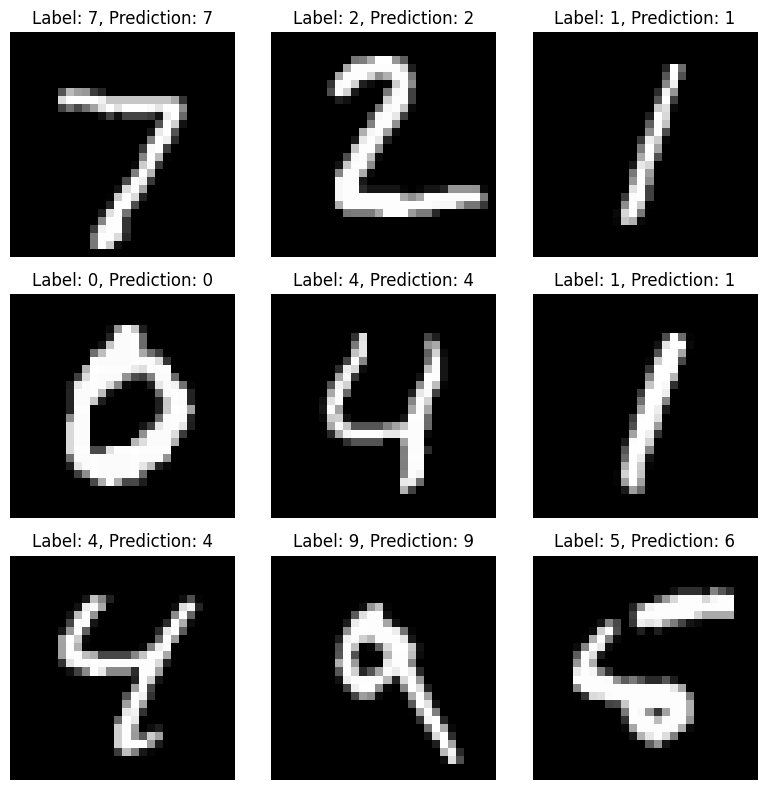

In [15]:
import os

if os.path.exists('mnist_model.pth'):
    # weights file found — skip training
    model = Net().to(device)
    model.load_state_dict(torch.load('mnist_model.pth', map_location=device))
    model.eval()
    print("Loaded saved weights. Skipping training.")
else:
    # no saved file — train from scratch and save
    for epoch in range(1, num_epochs + 1):
        train(model, device, train_loader, criterion, optimizer, epoch)
        test(model, device, test_loader, criterion)
    torch.save(model.state_dict(), 'mnist_model.pth')
    print("Training done. Weights saved.")


samples, labels = next(iter(test_loader))
samples = samples.to(device)
outputs = model(samples)
_, preds = torch.max(outputs, 1)

samples = samples.cpu().numpy()
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(samples[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i]}, Prediction: {preds[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()